# ConfigC — Exploración de variables de contexto de viento
Notebook unificado para `Exp271431`.  
Todas las figuras se guardan en `Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/`  
con nombres prefijados `ConfigC_`.


In [1]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ProjectRoot = Path("/data/users/kabasmen/MethaneProjectTFM")

if str(ProjectRoot) not in sys.path:
    sys.path.insert(0, str(ProjectRoot))

from Source.VisualizationStyle import (
    LoadVisualizationConfig,
    ApplyMatplotlibStyle,
    GetSaveParameters,
)
from Source.ReadTacoSample import ReadFullTacoSample

RunTag         = "Exp271431"
RunRoot        = ProjectRoot / "Outputs" / "Experiments" / RunTag
TablesRoot     = RunRoot / "Tables"
OutputFigureDir = RunRoot / "EDA" / "WindPlume" / "Figures"
OutputTableDir  = RunRoot / "EDA" / "WindPlume"

OutputFigureDir.mkdir(parents=True, exist_ok=True)
OutputTableDir.mkdir(parents=True, exist_ok=True)

VisualConfig = LoadVisualizationConfig(ProjectRoot / "Configs" / "VisualizationConfig.yaml")
ApplyMatplotlibStyle(VisualConfig)
SaveKw = GetSaveParameters(VisualConfig)

print("ProjectRoot    :", ProjectRoot)
print("OutputFigureDir:", OutputFigureDir)
print("OutputTableDir :", OutputTableDir)


ProjectRoot    : /data/users/kabasmen/MethaneProjectTFM
OutputFigureDir: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures
OutputTableDir : /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume


## 1. Carga de datos

In [2]:
InputTable = TablesRoot / "DatasetFiltered.csv"

DatasetFiltered = pd.read_csv(InputTable)

print("Rows   :", len(DatasetFiltered))
print("Columns:", len(DatasetFiltered.columns))

RequiredColumns = ["SampleId", "meteo:wind_u", "meteo:wind_v", "satellite:sza"]
MissingColumns  = [c for c in RequiredColumns if c not in DatasetFiltered.columns]

if MissingColumns:
    raise KeyError(f"Faltan columnas requeridas: {MissingColumns}")

DatasetFiltered[RequiredColumns].head()


Rows   : 3519
Columns: 46


,SampleId,meteo:wind_u,meteo:wind_v,satellite:sza
0,681256b9-41d5-4d9d-9063-d5fa17773661,-0.889798,-2.142312,36.481823
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,-1.876772,3.768559,16.324541
2,101031f1-3f77-4029-9172-fee5b35a6e5f,1.678992,0.428121,21.836166
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,-5.022003,5.710159,20.377953
4,2f334079-9187-4116-bf0a-f98d4bbd5236,-3.734330,2.595779,17.036350


## 2. Prototipo de capas para una muestra

In [3]:
SampleIndex = 0
SampleRow   = DatasetFiltered.iloc[SampleIndex]
SampleId    = str(SampleRow["SampleId"])

WindU        = float(SampleRow["meteo:wind_u"])
WindV        = float(SampleRow["meteo:wind_v"])
SolarZenith  = float(SampleRow["satellite:sza"])

print("SampleId   :", SampleId)
print("WindU      :", WindU)
print("WindV      :", WindV)
print("SolarZenith:", SolarZenith)


SampleId   : 681256b9-41d5-4d9d-9063-d5fa17773661
WindU      : -0.88979805
WindV      : -2.1423118
SolarZenith: 36.481823


In [4]:
Height = 200
Width  = 200

WindSpeed = math.sqrt(WindU ** 2 + WindV ** 2)

if WindSpeed > 0:
    WindSin = WindV / WindSpeed
    WindCos = WindU / WindSpeed
else:
    WindSin = 0.0
    WindCos = 0.0

WindDirectionRadians = math.atan2(WindV, WindU)
WindDirectionDegrees = (math.degrees(WindDirectionRadians) + 360.0) % 360.0
SolarZenithNorm      = SolarZenith / 90.0

ContextValues = {
    "SampleId": SampleId, "WindU": WindU, "WindV": WindV,
    "WindSpeed": WindSpeed, "WindDirectionDegrees": WindDirectionDegrees,
    "WindSin": WindSin, "WindCos": WindCos,
    "SolarZenith": SolarZenith, "SolarZenithNorm": SolarZenithNorm,
}
ContextValues


{'SampleId': '681256b9-41d5-4d9d-9063-d5fa17773661',
 'WindU': -0.88979805,
 'WindV': -2.1423118,
 'WindSpeed': 2.3197500766683987,
 'WindDirectionDegrees': 247.44469931851478,
 'WindSin': -0.9235097442379508,
 'WindCos': -0.3835749630744355,
 'SolarZenith': 36.481823,
 'SolarZenithNorm': 0.4053535888888889}

In [5]:
def ExpandScalar(Value, Height=200, Width=200):
    return np.full((Height, Width), float(Value), dtype=np.float32)

Layers = {
    "WindU":               ExpandScalar(WindU,               Height, Width),
    "WindV":               ExpandScalar(WindV,               Height, Width),
    "WindSpeed":           ExpandScalar(WindSpeed,           Height, Width),
    "WindDirectionDegrees":ExpandScalar(WindDirectionDegrees,Height, Width),
    "WindSin":             ExpandScalar(WindSin,             Height, Width),
    "WindCos":             ExpandScalar(WindCos,             Height, Width),
    "SolarZenithNorm":     ExpandScalar(SolarZenithNorm,     Height, Width),
}

for Name, Array in Layers.items():
    print(Name, Array.shape, float(Array.min()), float(Array.max()))


WindU (200, 200) -0.8897980451583862 -0.8897980451583862
WindV (200, 200) -2.1423118114471436 -2.1423118114471436
WindSpeed (200, 200) 2.3197500705718994 2.3197500705718994
WindDirectionDegrees (200, 200) 247.4447021484375 247.4447021484375
WindSin (200, 200) -0.9235097169876099 -0.9235097169876099
WindCos (200, 200) -0.3835749626159668 -0.3835749626159668
SolarZenithNorm (200, 200) 0.4053535759449005 0.4053535759449005


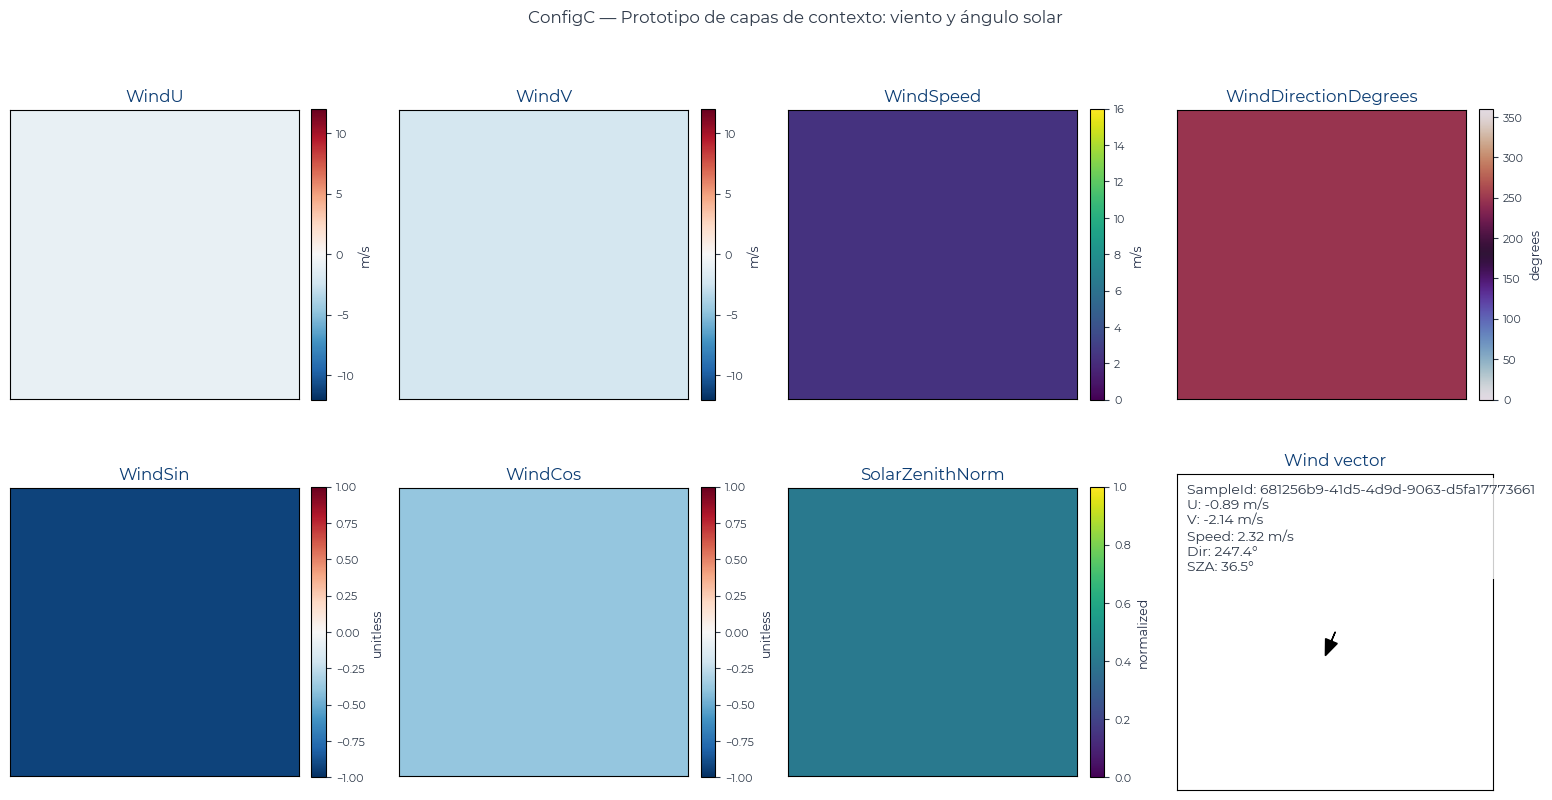

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/00_ConfigC_WindLayerPrototype_681256b9-41d5-4d9d-9063-d5fa17773661.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

PlotItems = [
    ("WindU",               "RdBu_r",  -12, 12,  "m/s"),
    ("WindV",               "RdBu_r",  -12, 12,  "m/s"),
    ("WindSpeed",           "viridis",   0, 16,  "m/s"),
    ("WindDirectionDegrees","twilight",  0, 360, "degrees"),
    ("WindSin",             "RdBu_r",  -1,  1,  "unitless"),
    ("WindCos",             "RdBu_r",  -1,  1,  "unitless"),
    ("SolarZenithNorm",     "viridis",   0,  1,  "normalized"),
]

for Axis, Item in zip(axes.flat, PlotItems):
    Name, Cmap, Vmin, Vmax, Label = Item
    Image = Axis.imshow(Layers[Name], cmap=Cmap, vmin=Vmin, vmax=Vmax)
    Axis.set_title(Name)
    Axis.set_xticks([]); Axis.set_yticks([])
    fig.colorbar(Image, ax=Axis, fraction=0.046, pad=0.04).set_label(Label)

# Último panel: vector de viento
Axis = axes.flat[-1]
Axis.set_title("Wind vector")
Axis.set_xlim(0, Width); Axis.set_ylim(Height, 0)
Axis.set_aspect("equal"); Axis.set_xticks([]); Axis.set_yticks([])
Scale = 7.0
Axis.arrow(Width/2, Height/2, WindU*Scale, -WindV*Scale,
           head_width=8, head_length=10, length_includes_head=True, color="black")
Axis.text(0.03, 0.97,
    f"SampleId: {SampleId}\nU: {WindU:.2f} m/s\nV: {WindV:.2f} m/s\n"
    f"Speed: {WindSpeed:.2f} m/s\nDir: {WindDirectionDegrees:.1f}°\nSZA: {SolarZenith:.1f}°",
    transform=Axis.transAxes, va="top", ha="left",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

fig.suptitle("ConfigC — Prototipo de capas de contexto: viento y ángulo solar", y=1.02)
fig.tight_layout()

OutputFigure = OutputFigureDir / f"00_ConfigC_WindLayerPrototype_{SampleId}.png"
fig.savefig(OutputFigure, **SaveKw)
plt.show()
print("Saved:", OutputFigure)


## 3. Exploración global del dataset

In [7]:
ContextRows = []

for _, Row in DatasetFiltered.iterrows():
    Sid   = str(Row["SampleId"])
    U     = float(Row["meteo:wind_u"])
    V     = float(Row["meteo:wind_v"])
    SZA   = float(Row["satellite:sza"])
    Speed = math.sqrt(U**2 + V**2)
    WSin  = V / Speed if Speed > 0 else 0.0
    WCos  = U / Speed if Speed > 0 else 0.0
    WDir  = (math.degrees(math.atan2(V, U)) + 360.0) % 360.0
    SZANorm = SZA / 90.0
    ContextRows.append({
        "SampleId": Sid, "WindU": U, "WindV": V, "WindSpeed": Speed,
        "WindDirectionDegrees": WDir, "WindSin": WSin, "WindCos": WCos,
        "SolarZenith": SZA, "SolarZenithNorm": SZANorm,
    })

WindContextBySample = pd.DataFrame(ContextRows)

NumericColumns = ["WindU","WindV","WindSpeed","WindDirectionDegrees",
                  "WindSin","WindCos","SolarZenith","SolarZenithNorm"]

if not np.isfinite(WindContextBySample[NumericColumns].to_numpy(dtype=float)).all():
    raise ValueError("WindContextBySample contiene NaN o Inf.")

WindContextBySample.to_csv(OutputTableDir / "WindContextBySample.csv", index=False)
print("Rows:", len(WindContextBySample))
WindContextBySample.head()


Rows: 3519


,SampleId,WindU,WindV,WindSpeed,WindDirectionDegrees,WindSin,WindCos,SolarZenith,SolarZenithNorm
0,681256b9-41d5-4d9d-9063-d5fa17773661,-0.889798,-2.142312,2.319750,247.444699,-0.923510,-0.383575,36.481823,0.405354
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,-1.876772,3.768559,4.210025,116.473658,0.895139,-0.445786,16.324541,0.181384
2,101031f1-3f77-4029-9172-fee5b35a6e5f,1.678992,0.428121,1.732715,14.304853,0.247081,0.968995,21.836166,0.242624
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,-5.022003,5.710159,7.604369,131.331164,0.750905,-0.660410,20.377953,0.226422
4,2f334079-9187-4116-bf0a-f98d4bbd5236,-3.734330,2.595779,4.547889,145.196355,0.570766,-0.821113,17.036350,0.189293


In [8]:
SummaryRows = []
for Column in NumericColumns:
    Values = WindContextBySample[Column].to_numpy(dtype=float)
    SummaryRows.append({
        "Variable": Column,
        "Count":  int(len(Values)),
        "Mean":   float(np.mean(Values)),
        "Std":    float(np.std(Values)),
        "Min":    float(np.min(Values)),
        "P05":    float(np.percentile(Values, 5)),
        "P25":    float(np.percentile(Values, 25)),
        "Median": float(np.percentile(Values, 50)),
        "P75":    float(np.percentile(Values, 75)),
        "P95":    float(np.percentile(Values, 95)),
        "Max":    float(np.max(Values)),
    })

WS = WindContextBySample["WindSpeed"].to_numpy(dtype=float)
for Thr in [0.5, 1.0]:
    SummaryRows.append({"Variable": f"WindSpeedBelow{Thr}ms",
                        "Count": int((WS < Thr).sum()),
                        "Mean": float((WS < Thr).mean()),
                        **{k: np.nan for k in ["Std","Min","P05","P25","Median","P75","P95","Max"]}})

WindContextSummary = pd.DataFrame(SummaryRows)
WindContextSummary.to_csv(OutputTableDir / "WindContextSummary.csv", index=False)
print("Saved: WindContextSummary.csv")
WindContextSummary


Saved: WindContextSummary.csv


,Variable,Count,Mean,Std,Min,P05,P25,Median,P75,P95,Max
0,WindU,3519,-0.790657,3.109673,-11.296280,-5.800775,-3.028322,-0.798802,1.427979,4.339076,9.166214
1,WindV,3519,0.136295,2.800202,-9.783691,-4.498568,-1.654669,0.146042,2.088004,4.572535,9.935712
2,WindSpeed,3519,3.787961,1.950964,0.089677,0.987456,2.316574,3.579583,5.034123,7.372794,12.166351
3,WindDirectionDegrees,3519,180.865806,94.296365,0.164255,23.946747,115.522070,175.031578,253.739806,340.780234,359.930701
4,WindSin,3519,0.026575,0.675558,-1.000000,-0.980155,-0.611005,0.060136,0.675334,0.981182,1.000000
5,WindCos,3519,-0.164943,0.718129,-0.999999,-0.993891,-0.862941,-0.366102,0.535515,0.980835,0.999999
6,SolarZenith,3519,35.650639,13.600950,15.835876,18.700092,23.123151,32.995403,47.637525,58.089724,68.336130
7,SolarZenithNorm,3519,0.396118,0.151122,0.175954,0.207779,0.256924,0.366616,0.529306,0.645441,0.759290
8,WindSpeedBelow0.5ms,48,0.013640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,WindSpeedBelow1.0ms,182,0.051719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Figura de visión general (ConfigC context overview)

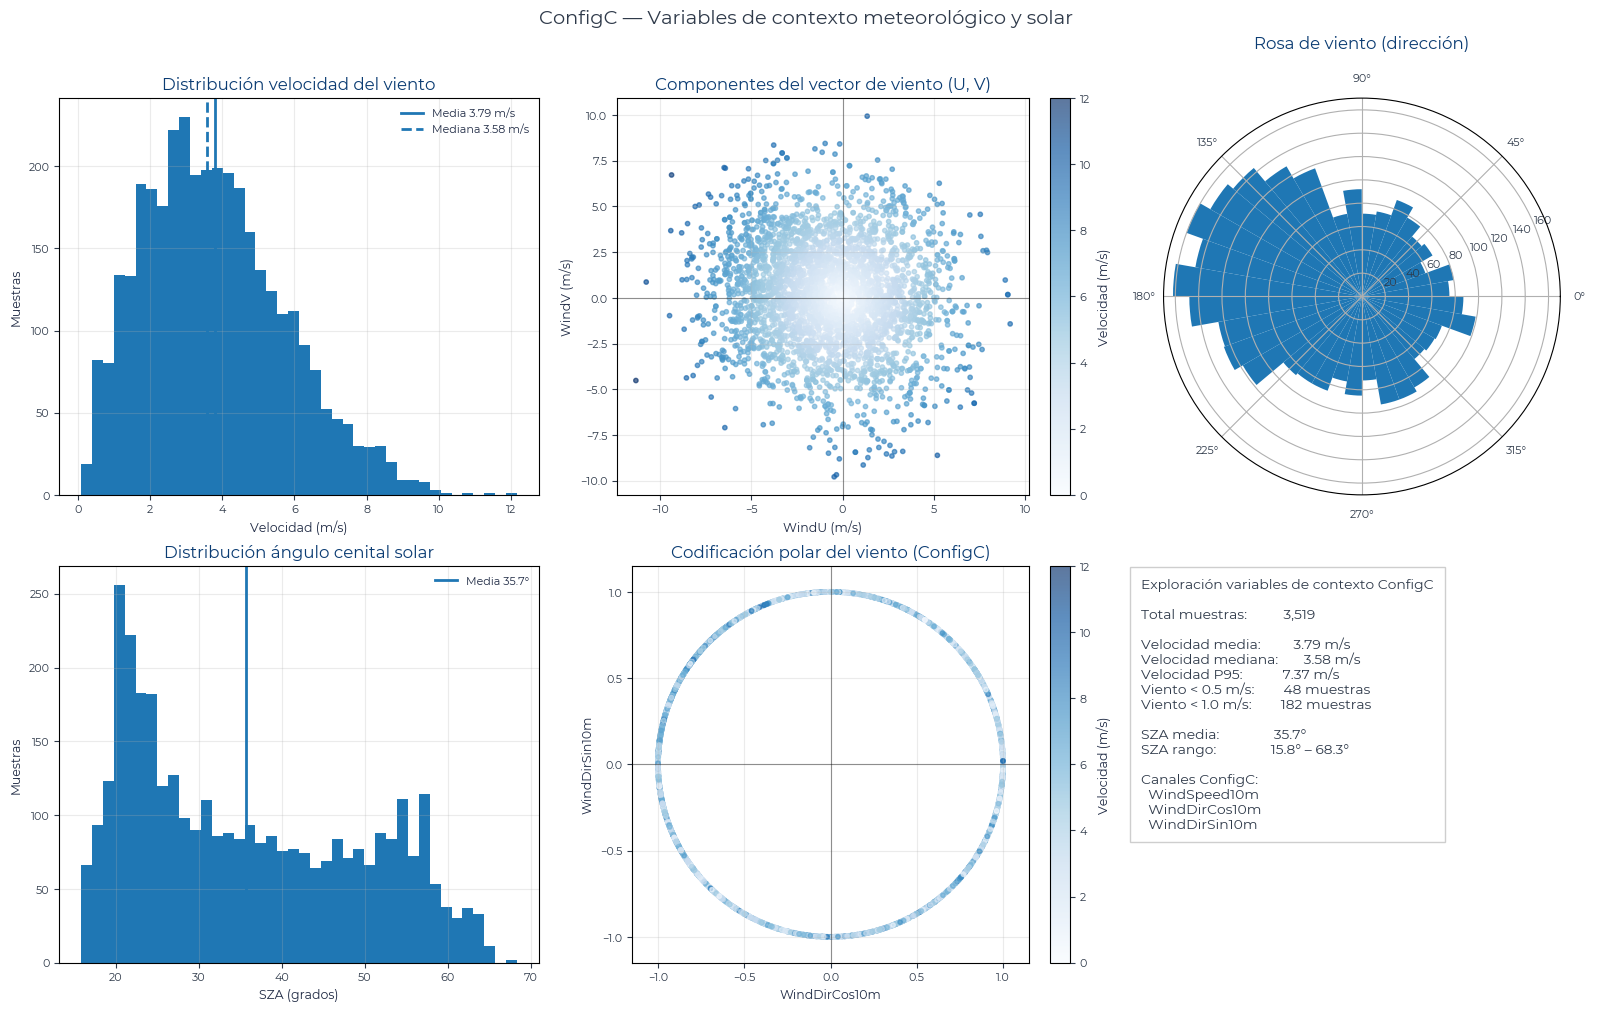

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/01_ConfigC_WindContextOverview.png


In [9]:
WS   = WindContextBySample["WindSpeed"].to_numpy(dtype=float)
WU   = WindContextBySample["WindU"].to_numpy(dtype=float)
WV   = WindContextBySample["WindV"].to_numpy(dtype=float)
WDir = np.deg2rad(WindContextBySample["WindDirectionDegrees"].to_numpy(dtype=float))
SZA  = WindContextBySample["SolarZenith"].to_numpy(dtype=float)
WSin = WindContextBySample["WindSin"].to_numpy(dtype=float)
WCos = WindContextBySample["WindCos"].to_numpy(dtype=float)

Figure = plt.figure(figsize=(16, 10), constrained_layout=True)
Grid   = Figure.add_gridspec(2, 3)

AxisSpeed     = Figure.add_subplot(Grid[0, 0])
AxisUV        = Figure.add_subplot(Grid[0, 1])
AxisDirection = Figure.add_subplot(Grid[0, 2], projection="polar")
AxisZenith    = Figure.add_subplot(Grid[1, 0])
AxisSinCos    = Figure.add_subplot(Grid[1, 1])
AxisText      = Figure.add_subplot(Grid[1, 2])

AxisSpeed.hist(WS, bins=40)
AxisSpeed.axvline(WS.mean(),   linewidth=2, label=f"Media {WS.mean():.2f} m/s")
AxisSpeed.axvline(np.median(WS), linewidth=2, linestyle="--", label=f"Mediana {np.median(WS):.2f} m/s")
AxisSpeed.set_title("Distribución velocidad del viento")
AxisSpeed.set_xlabel("Velocidad (m/s)"); AxisSpeed.set_ylabel("Muestras")
AxisSpeed.legend(frameon=False); AxisSpeed.grid(alpha=0.25)

ScUV = AxisUV.scatter(WU, WV, c=WS, s=10, alpha=0.65, cmap="Blues", vmin=0, vmax=12)
AxisUV.axhline(0, lw=0.8, color="black", alpha=0.4)
AxisUV.axvline(0, lw=0.8, color="black", alpha=0.4)
AxisUV.set_title("Componentes del vector de viento (U, V)")
AxisUV.set_xlabel("WindU (m/s)"); AxisUV.set_ylabel("WindV (m/s)")
AxisUV.set_aspect("equal", adjustable="box"); AxisUV.grid(alpha=0.25)
Figure.colorbar(ScUV, ax=AxisUV, fraction=0.046, pad=0.04).set_label("Velocidad (m/s)")

AxisDirection.hist(WDir, bins=36)
AxisDirection.set_title("Rosa de viento (dirección)", pad=18)
AxisDirection.set_theta_zero_location("E"); AxisDirection.set_theta_direction(1)

AxisZenith.hist(SZA, bins=40)
AxisZenith.axvline(SZA.mean(), lw=2, label=f"Media {SZA.mean():.1f}°")
AxisZenith.set_title("Distribución ángulo cenital solar")
AxisZenith.set_xlabel("SZA (grados)"); AxisZenith.set_ylabel("Muestras")
AxisZenith.legend(frameon=False); AxisZenith.grid(alpha=0.25)

ScPol = AxisSinCos.scatter(WCos, WSin, c=WS, s=10, alpha=0.65, cmap="Blues", vmin=0, vmax=12)
AxisSinCos.axhline(0, lw=0.8, color="black", alpha=0.4)
AxisSinCos.axvline(0, lw=0.8, color="black", alpha=0.4)
Theta = np.linspace(0, 2*np.pi, 200)
AxisSinCos.plot(np.cos(Theta), np.sin(Theta), color="#AAAAAA", lw=0.8, ls="--", zorder=0)
AxisSinCos.set_title("Codificación polar del viento (ConfigC)")
AxisSinCos.set_xlabel("WindDirCos10m"); AxisSinCos.set_ylabel("WindDirSin10m")
AxisSinCos.set_aspect("equal"); AxisSinCos.set_xlim(-1.15, 1.15); AxisSinCos.set_ylim(-1.15, 1.15)
AxisSinCos.grid(alpha=0.25)
Figure.colorbar(ScPol, ax=AxisSinCos, fraction=0.046, pad=0.04).set_label("Velocidad (m/s)")

AxisText.axis("off")
TextLines = [
    "Exploración variables de contexto ConfigC", "",
    f"Total muestras:          {len(WindContextBySample):,}", "",
    f"Velocidad media:         {WS.mean():.2f} m/s",
    f"Velocidad mediana:       {np.median(WS):.2f} m/s",
    f"Velocidad P95:           {np.percentile(WS, 95):.2f} m/s",
    f"Viento < 0.5 m/s:        {(WS < 0.5).sum()} muestras",
    f"Viento < 1.0 m/s:        {(WS < 1.0).sum()} muestras", "",
    f"SZA media:               {SZA.mean():.1f}°",
    f"SZA rango:               {SZA.min():.1f}° – {SZA.max():.1f}°", "",
    "Canales ConfigC:",
    "  WindSpeed10m",
    "  WindDirCos10m",
    "  WindDirSin10m",
]
AxisText.text(0.04, 0.97, "\n".join(TextLines), ha="left", va="top", fontsize=10,
    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.95, pad=8))

Figure.suptitle("ConfigC — Variables de contexto meteorológico y solar", fontsize=14)

OutputFig = OutputFigureDir / "01_ConfigC_WindContextOverview.png"
Figure.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


## 5. Análisis de alineación viento–pluma

In [10]:
def PlumeGeometry(PlumeMask):
    Mask   = np.asarray(PlumeMask) > 0
    Coords = np.argwhere(Mask)
    if Coords.shape[0] < 5:
        return {"PlumePixels": int(Coords.shape[0]),
                "CentroidRow": np.nan, "CentroidCol": np.nan,
                "PlumeAngleMathRad": np.nan,
                "MajorStd": np.nan, "MinorStd": np.nan, "Elongation": np.nan}
    Rows, Cols = Coords[:, 0].astype(float), Coords[:, 1].astype(float)
    CR, CC = Rows.mean(), Cols.mean()
    X, Y   = Cols - CC, -(Rows - CR)
    Cov    = np.cov(np.vstack([X, Y]), rowvar=False)
    Eigvals, Eigvecs = np.linalg.eigh(Cov)
    Order  = np.argsort(Eigvals)[::-1]
    Eigvals, Eigvecs = Eigvals[Order], Eigvecs[:, Order]
    MajorVec = Eigvecs[:, 0]
    Angle    = np.arctan2(MajorVec[1], MajorVec[0])
    Maj      = np.sqrt(max(Eigvals[0], 0))
    Min_     = np.sqrt(max(Eigvals[1], 0))
    return {"PlumePixels": int(Coords.shape[0]),
            "CentroidRow": float(CR), "CentroidCol": float(CC),
            "PlumeAngleMathRad": float(Angle),
            "MajorStd": float(Maj), "MinorStd": float(Min_),
            "Elongation": float(Maj / (Min_ + 1e-6))}


def GetSplitIds(SplitName, MaxSamples=None, RandomSeed=42):
    Path_ = TablesRoot / f"Split{SplitName}FeatureReady.csv"
    if not Path_.exists():
        raise FileNotFoundError(Path_)
    Df = pd.read_csv(Path_)
    Df["SampleId"] = Df["SampleId"].astype(str)
    if MaxSamples and len(Df) > MaxSamples:
        Df = Df.sample(n=MaxSamples, random_state=RandomSeed)
    return Df["SampleId"].tolist()


print("Funciones PlumeGeometry y GetSplitIds definidas.")


Funciones PlumeGeometry y GetSplitIds definidas.


In [11]:
# Construir SampleTable con columnas de viento desde DatasetFiltered
SampleTable = DatasetFiltered.copy()
SampleTable["SampleId"] = SampleTable["SampleId"].astype(str)

Eps = 1e-6
SampleTable["WindU"]          = pd.to_numeric(SampleTable["meteo:wind_u"], errors="coerce")
SampleTable["WindV"]          = pd.to_numeric(SampleTable["meteo:wind_v"], errors="coerce")
SampleTable["WindSpeed10m"]   = np.sqrt(SampleTable["WindU"]**2 + SampleTable["WindV"]**2)
SampleTable["WindDirRad_To"]  = np.arctan2(SampleTable["WindV"], SampleTable["WindU"])
SampleTable["WindDirDeg_To"]  = (np.degrees(SampleTable["WindDirRad_To"]) + 360) % 360
SampleTable["WindDirCos10m"]  = SampleTable["WindU"] / (SampleTable["WindSpeed10m"] + Eps)
SampleTable["WindDirSin10m"]  = SampleTable["WindV"] / (SampleTable["WindSpeed10m"] + Eps)

WindSourceCol = "detection:wind_source"

print("SampleTable:", SampleTable.shape)
SampleTable[["SampleId", WindSourceCol, "WindU", "WindV", "WindSpeed10m", "WindDirDeg_To"]].head()


SampleTable: (3519, 53)


,SampleId,detection:wind_source,WindU,WindV,WindSpeed10m,WindDirDeg_To
0,681256b9-41d5-4d9d-9063-d5fa17773661,NASA/GEOS-FP,-0.889798,-2.142312,2.319750,247.444699
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,NASA/GEOS-FP,-1.876772,3.768559,4.210025,116.473658
2,101031f1-3f77-4029-9172-fee5b35a6e5f,NASA/GEOS-FP,1.678992,0.428121,1.732715,14.304853
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,ECMWF/ERA5_LAND/HOURLY,-5.022003,5.710159,7.604369,131.331164
4,2f334079-9187-4116-bf0a-f98d4bbd5236,ECMWF/ERA5_LAND/HOURLY,-3.734330,2.595779,4.547889,145.196355


In [12]:
from Source.TacoIndex import LoadTacoDataset, GetSampleTable as GetTacoSampleTable
from Source.ReadTacoSample import ReadFullTacoSample

DatasetPath = Path("/data/databases/METHANE_DATASETS_TACOv2")
TacoDataset, _ = LoadTacoDataset(DatasetPath, "methaneset-s2-finetune")
TacoSampleTable = GetTacoSampleTable(TacoDataset)

print("TacoSampleTable:", TacoSampleTable.shape)


TacoSampleTable: (3612, 39)


In [13]:
MaxSamplesPerSplit = 150
RandomSeed         = 42

SampleMetaCols = ["SampleId", WindSourceCol, "WindU", "WindV",
                  "WindSpeed10m", "WindDirRad_To", "WindDirDeg_To",
                  "WindDirCos10m", "WindDirSin10m"]
SampleMeta = SampleTable[SampleMetaCols].copy()

EdaRows = []

for Split in ["Train", "Validation", "Test"]:
    SampleIds = GetSplitIds(Split, MaxSamples=MaxSamplesPerSplit, RandomSeed=RandomSeed)
    print(f"Procesando {Split}: {len(SampleIds)} muestras")

    for I, Sid in enumerate(SampleIds, 1):
        Sample = ReadFullTacoSample(
            Dataset=TacoDataset,
            SampleTable=TacoSampleTable,
            SampleId=Sid,
        )
        Geom = PlumeGeometry(Sample["Plume"])
        Meta = SampleMeta[SampleMeta["SampleId"] == Sid]
        if Meta.empty:
            continue
        Meta = Meta.iloc[0].to_dict()

        WA = Meta["WindDirRad_To"]
        PA = Geom["PlumeAngleMathRad"]
        if np.isfinite(WA) and np.isfinite(PA):
            Alignment  = abs(np.cos(PA - WA))
            AngleDiff  = np.degrees(np.arccos(np.clip(Alignment, -1, 1)))
        else:
            Alignment = AngleDiff = np.nan

        EdaRows.append({"Split": Split, "SampleId": Sid,
                        **Meta, **Geom,
                        "WindPlumeAlignmentAbsCos": Alignment,
                        "WindPlumeAngleDiffDeg_Axis": AngleDiff})
        if I % 50 == 0:
            print(f"  {Split}: {I}/{len(SampleIds)}")

WindPlumeEDA = pd.DataFrame(EdaRows)
WindPlumeEDA.to_csv(OutputTableDir / "WindPlumeGeometryEDA.csv", index=False)
print("\nWindPlumeEDA:", WindPlumeEDA.shape)
WindPlumeEDA.head()


Procesando Train: 150 muestras
  Train: 50/150
  Train: 100/150
  Train: 150/150
Procesando Validation: 150 muestras
  Validation: 50/150
  Validation: 100/150
  Validation: 150/150
Procesando Test: 150 muestras
  Test: 50/150
  Test: 100/150
  Test: 150/150

WindPlumeEDA: (450, 19)


,Split,SampleId,detection:wind_source,WindU,WindV,WindSpeed10m,WindDirRad_To,WindDirDeg_To,WindDirCos10m,WindDirSin10m,PlumePixels,CentroidRow,CentroidCol,PlumeAngleMathRad,MajorStd,MinorStd,Elongation,WindPlumeAlignmentAbsCos,WindPlumeAngleDiffDeg_Axis
0,Train,318f229d-62aa-45b5-85fd-579da4e8bbbe,NASA/GEOS-FP,-0.150274,2.049384,2.054886,1.643992,94.193778,-0.073130,0.997322,1956,122.017382,132.940695,0.774863,756.227004,0.000021,3.379869e+07,0.645492,49.797402
1,Train,b2fe7593-1db0-4683-9cf1-5c658457cc4b,ECMWF/ERA5_LAND/HOURLY,-5.110443,2.448048,5.666530,2.694863,154.404253,-0.901864,0.432019,1640,141.304878,140.446341,0.773565,499.671141,0.000014,3.254772e+07,0.343369,69.917741
2,Train,937e68c0-d68f-48f0-be3e-f17573104548,NASA/GEOS-FP,3.778542,-1.581461,4.096144,-0.396384,337.288868,0.922463,-0.386085,729,155.705075,88.930041,0.776798,853.871460,0.000015,5.216990e+07,0.387220,67.218363
3,Train,c5274417-b18e-42e8-896b-43d6345fe71c,ECMWF/ERA5_LAND/HOURLY,-1.306549,1.560776,2.035459,2.267762,129.933212,-0.641894,0.766793,867,86.755479,71.978085,0.821760,488.800293,0.000009,4.805872e+07,0.124471,82.849817
4,Train,d7985fe1-b429-4780-99c1-93cc707d4f3a,ECMWF/ERA5_LAND/HOURLY,-3.973343,-0.273697,3.982758,-3.072818,183.940497,-0.997636,-0.068720,1129,176.879539,32.354296,0.773418,499.341700,0.000010,4.636387e+07,0.761843,40.373093


### 5.1 Velocidad del viento vs geometría de pluma

/tmp/ipykernel_2874221/211674788.py:20: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Montserrat.
  Fig.tight_layout()
/tmp/ipykernel_2874221/211674788.py:22: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Montserrat.
  Fig.savefig(OutputFig, **SaveKw)
/data/users/kabasmen/.conda/envs/deep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Montserrat.
  fig.canvas.print_figure(bytes_io, **kw)


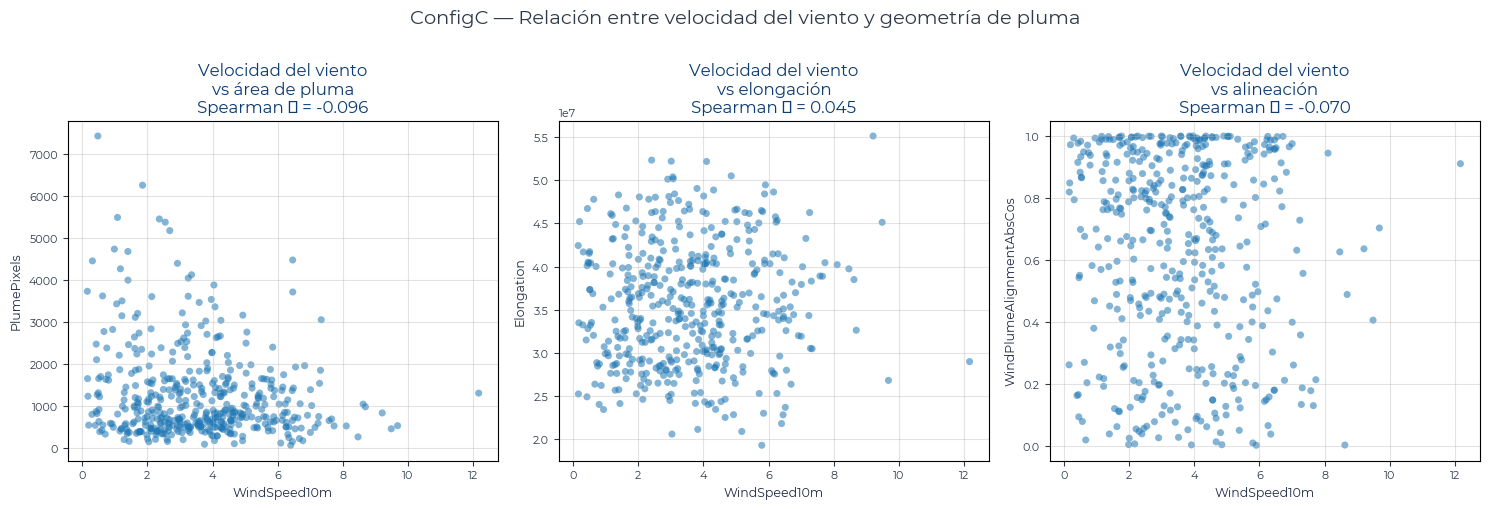

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/02_ConfigC_WindSpeed_vs_PlumeGeometry.png


In [14]:
PlotDf = WindPlumeEDA.copy()
Pairs  = [
    ("WindSpeed10m", "PlumePixels",             "Velocidad del viento\nvs área de pluma"),
    ("WindSpeed10m", "Elongation",              "Velocidad del viento\nvs elongación"),
    ("WindSpeed10m", "WindPlumeAlignmentAbsCos","Velocidad del viento\nvs alineación"),
]

Fig, Axes = plt.subplots(1, 3, figsize=(15, 5))

for Ax, (Xcol, Ycol, Title) in zip(Axes, Pairs):
    Df  = PlotDf[np.isfinite(PlotDf[Xcol]) & np.isfinite(PlotDf[Ycol])].copy()
    Rho = Df[[Xcol, Ycol]].corr(method="spearman").iloc[0, 1]
    Ax.scatter(Df[Xcol], Df[Ycol], s=26, alpha=0.55, edgecolor="none")
    Ax.set_title(f"{Title}\nSpearman ρ = {Rho:.3f}")
    Ax.set_xlabel(Xcol); Ax.set_ylabel(Ycol)
    Ax.grid(alpha=0.35)

Fig.suptitle("ConfigC — Relación entre velocidad del viento y geometría de pluma",
             fontsize=14, y=1.01)
Fig.tight_layout()
OutputFig = OutputFigureDir / "02_ConfigC_WindSpeed_vs_PlumeGeometry.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


### 5.2 Distribución de alineación viento–pluma

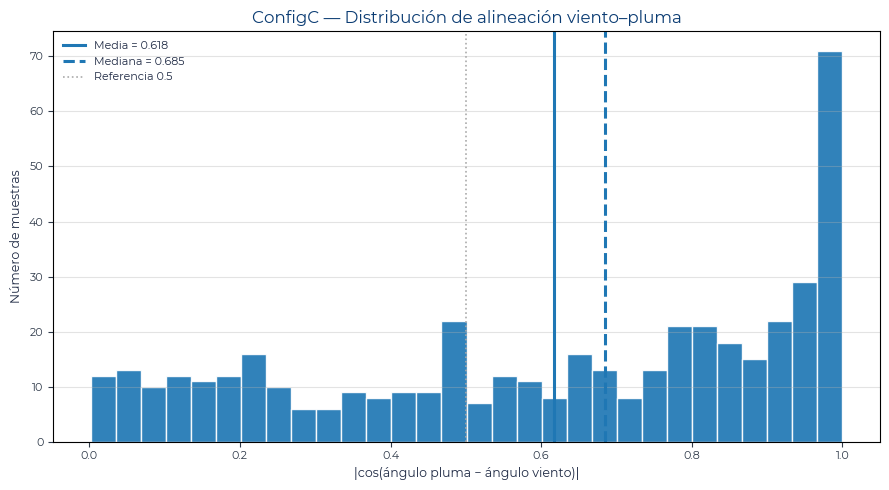

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/03_ConfigC_WindPlumeAlignment_Distribution.png


In [15]:
ValidAlign = WindPlumeEDA["WindPlumeAlignmentAbsCos"].dropna()

Fig, Ax = plt.subplots(figsize=(9, 5))
Ax.hist(ValidAlign, bins=30, edgecolor="white", alpha=0.92)
Ax.axvline(ValidAlign.mean(),   lw=2.2, label=f"Media = {ValidAlign.mean():.3f}")
Ax.axvline(ValidAlign.median(), lw=2.2, ls="--", label=f"Mediana = {ValidAlign.median():.3f}")
Ax.axvline(0.5, color="#AAAAAA", lw=1.2, ls=":", label="Referencia 0.5")
Ax.set_title("ConfigC — Distribución de alineación viento–pluma")
Ax.set_xlabel("|cos(ángulo pluma − ángulo viento)|")
Ax.set_ylabel("Número de muestras")
Ax.legend(frameon=False); Ax.grid(True, axis="y", alpha=0.35)
Fig.tight_layout()
OutputFig = OutputFigureDir / "03_ConfigC_WindPlumeAlignment_Distribution.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


### 5.3 Alineación por fuente meteorológica

/tmp/ipykernel_2874221/1248775197.py:21: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  Fig.tight_layout()
/tmp/ipykernel_2874221/1248775197.py:23: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  Fig.savefig(OutputFig, **SaveKw)
/data/users/kabasmen/.conda/envs/deep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  fig.canvas.print_figure(bytes_io, **kw)


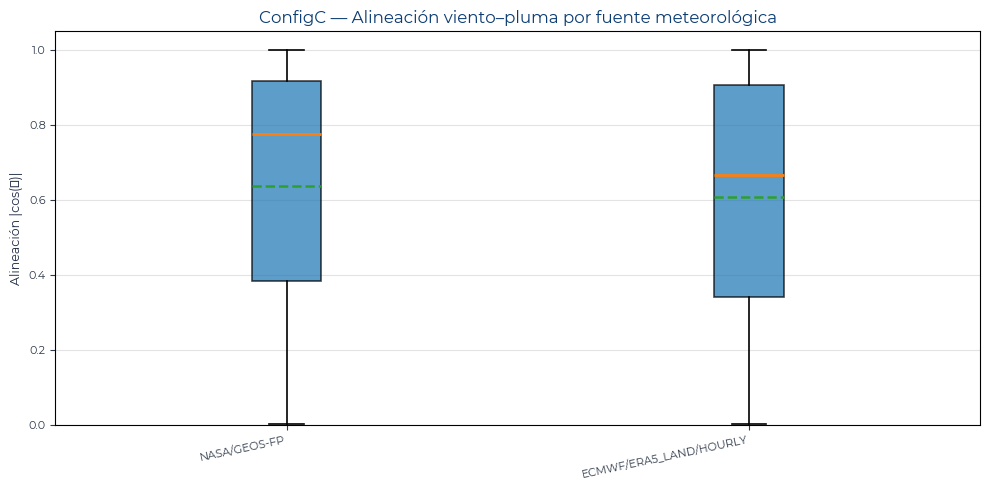

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/04_ConfigC_WindPlumeAlignment_ByWindSource.png


In [16]:
Sources  = [s for s in WindPlumeEDA[WindSourceCol].dropna().unique()
             if WindPlumeEDA[WindPlumeEDA[WindSourceCol] == s].shape[0] >= 5]
DataSrc  = [WindPlumeEDA.loc[WindPlumeEDA[WindSourceCol] == s,
                              "WindPlumeAlignmentAbsCos"].dropna().values
            for s in Sources]

Fig, Ax = plt.subplots(figsize=(10, 5))
BP = Ax.boxplot(DataSrc, tick_labels=Sources, patch_artist=True,
                showmeans=True, meanline=True,
                medianprops=dict(linewidth=2),
                meanprops=dict(linewidth=1.8, ls="--"),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, alpha=0.6, linestyle="none"))
for Patch in BP["boxes"]:
    Patch.set_alpha(0.72); Patch.set_linewidth(1.2)
Ax.set_title("ConfigC — Alineación viento–pluma por fuente meteorológica")
Ax.set_ylabel("Alineación |cos(δ)|"); Ax.set_ylim(0, 1.05)
Ax.grid(True, axis="y", alpha=0.35)
plt.xticks(rotation=12, ha="right")
Fig.tight_layout()
OutputFig = OutputFigureDir / "04_ConfigC_WindPlumeAlignment_ByWindSource.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


### 5.4 Homogeneidad de alineación entre splits

/tmp/ipykernel_2874221/3992091116.py:18: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  Fig.tight_layout()
/tmp/ipykernel_2874221/3992091116.py:20: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  Fig.savefig(OutputFig, **SaveKw)
/data/users/kabasmen/.conda/envs/deep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  fig.canvas.print_figure(bytes_io, **kw)


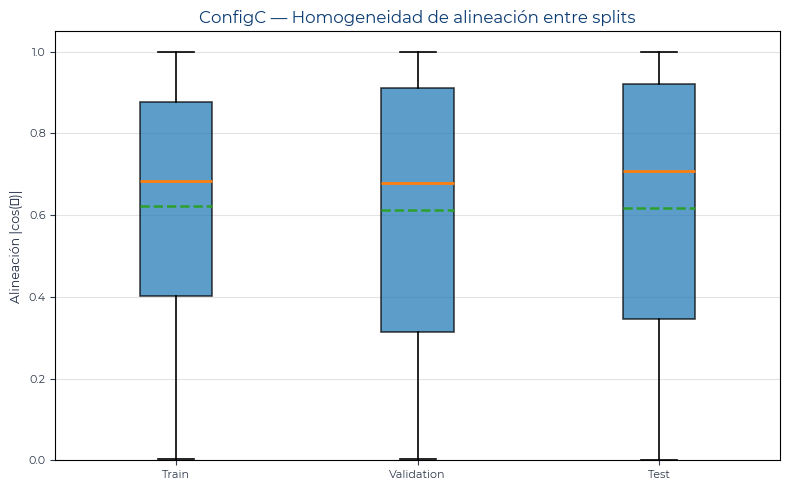

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/05_ConfigC_WindPlumeAlignment_BySplit.png

Estadísticas por split:
Split        Test       Train  Validation
count  150.000000  150.000000  150.000000
mean     0.617160    0.623083    0.612706
std      0.329513    0.299917    0.322862
min      0.001837    0.003077    0.002572
25%      0.344768    0.402391    0.313252
50%      0.709119    0.683966    0.678838
75%      0.921065    0.876233    0.910702
max      0.999972    0.999967    0.999913


In [17]:
SplitsOrder = ["Train", "Validation", "Test"]
DataSplits  = [WindPlumeEDA.loc[WindPlumeEDA["Split"] == S,
                                 "WindPlumeAlignmentAbsCos"].dropna().values
               for S in SplitsOrder]

Fig, Ax = plt.subplots(figsize=(8, 5))
BP = Ax.boxplot(DataSplits, tick_labels=SplitsOrder, patch_artist=True,
                showmeans=True, meanline=True,
                medianprops=dict(linewidth=2),
                meanprops=dict(linewidth=1.8, ls="--"),
                whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, alpha=0.6, linestyle="none"))
for Patch in BP["boxes"]:
    Patch.set_alpha(0.72); Patch.set_linewidth(1.2)
Ax.set_title("ConfigC — Homogeneidad de alineación entre splits")
Ax.set_ylabel("Alineación |cos(δ)|"); Ax.set_ylim(0, 1.05)
Ax.grid(True, axis="y", alpha=0.35)
Fig.tight_layout()
OutputFig = OutputFigureDir / "05_ConfigC_WindPlumeAlignment_BySplit.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)

# Tabla resumen numérico por split
print("\nEstadísticas por split:")
print(WindPlumeEDA.groupby("Split")["WindPlumeAlignmentAbsCos"].describe().T)


### 5.5 Robustez de la alineación según tamaño de pluma

In [18]:
Thresholds  = [0, 25, 50, 100, 200, 300, 500, 1000]
RobustRows  = []

for Thr in Thresholds:
    Df = WindPlumeEDA[
        (WindPlumeEDA["PlumePixels"] >= Thr)
        & np.isfinite(WindPlumeEDA["WindPlumeAlignmentAbsCos"])
        & np.isfinite(WindPlumeEDA["WindSpeed10m"])
        & np.isfinite(WindPlumeEDA["Elongation"])
    ].copy()
    if len(Df) == 0:
        continue
    RobustRows.append({
        "MinPlumePixels":                  Thr,
        "Samples":                         len(Df),
        "AlignmentMean":                   Df["WindPlumeAlignmentAbsCos"].mean(),
        "AlignmentMedian":                 Df["WindPlumeAlignmentAbsCos"].median(),
        "AlignmentP25":                    Df["WindPlumeAlignmentAbsCos"].quantile(0.25),
        "AlignmentP75":                    Df["WindPlumeAlignmentAbsCos"].quantile(0.75),
        "Spearman_WindSpeed_Elongation":   Df[["WindSpeed10m","Elongation"]].corr(method="spearman").iloc[0,1],
        "Spearman_WindSpeed_PlumePixels":  Df[["WindSpeed10m","PlumePixels"]].corr(method="spearman").iloc[0,1],
        "Spearman_WindSpeed_Alignment":    Df[["WindSpeed10m","WindPlumeAlignmentAbsCos"]].corr(method="spearman").iloc[0,1],
    })

RobustAlignment = pd.DataFrame(RobustRows)
RobustAlignment.to_csv(OutputTableDir / "WindPlumeAlignment_RobustnessByPlumeSize.csv", index=False)
RobustAlignment


,MinPlumePixels,Samples,AlignmentMean,AlignmentMedian,AlignmentP25,AlignmentP75,Spearman_WindSpeed_Elongation,Spearman_WindSpeed_PlumePixels,Spearman_WindSpeed_Alignment
0,0,450,0.617650,0.685041,0.343633,0.910702,0.045377,-0.095896,-0.070482
1,25,450,0.617650,0.685041,0.343633,0.910702,0.045377,-0.095896,-0.070482
2,50,450,0.617650,0.685041,0.343633,0.910702,0.045377,-0.095896,-0.070482
3,100,448,0.618719,0.690503,0.344161,0.911347,0.052263,-0.090526,-0.067391
4,200,439,0.622010,0.694467,0.353958,0.914022,0.058075,-0.079147,-0.053243
5,300,428,0.618965,0.690503,0.350961,0.911740,0.058393,-0.072946,-0.058552
6,500,361,0.607832,0.666920,0.341552,0.905846,0.077399,-0.169086,-0.068721
7,1000,207,0.625543,0.698418,0.369507,0.909196,0.055766,-0.237842,0.039867


/tmp/ipykernel_2874221/2880627013.py:25: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  Fig.tight_layout()
/tmp/ipykernel_2874221/2880627013.py:27: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  Fig.savefig(OutputFig, **SaveKw)
/data/users/kabasmen/.conda/envs/deep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Montserrat.
  fig.canvas.print_figure(bytes_io, **kw)


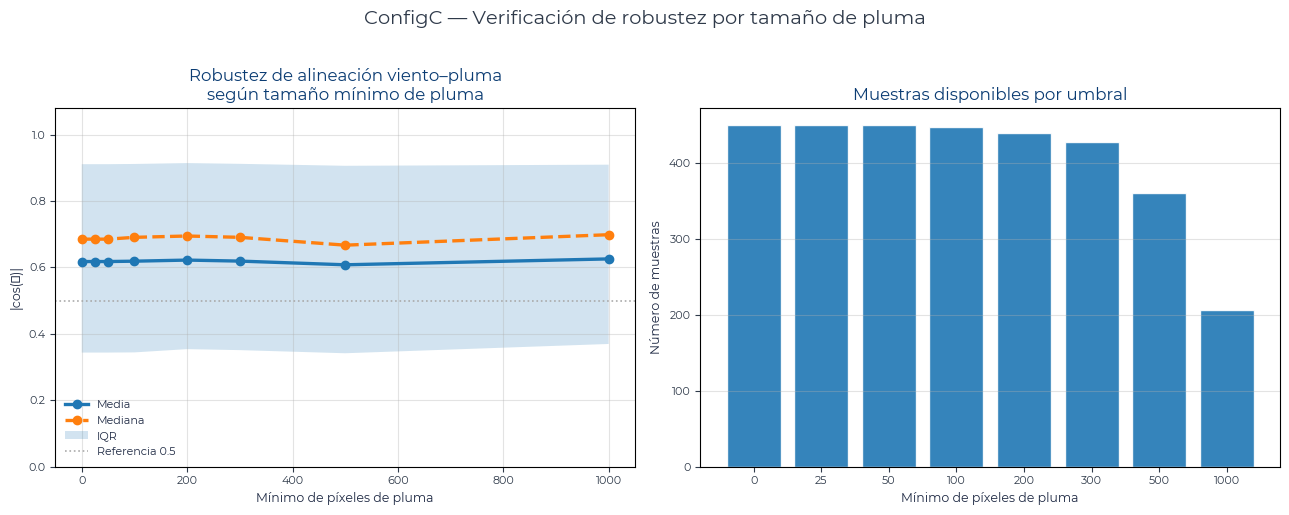

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/06_ConfigC_WindPlumeAlignment_RobustnessByPlumeSize.png


In [19]:
Fig, Axes = plt.subplots(1, 2, figsize=(13, 5))

Ax = Axes[0]
Ax.plot(RobustAlignment["MinPlumePixels"], RobustAlignment["AlignmentMean"],
        marker="o", lw=2.4, label="Media")
Ax.plot(RobustAlignment["MinPlumePixels"], RobustAlignment["AlignmentMedian"],
        marker="o", lw=2.4, ls="--", label="Mediana")
Ax.fill_between(RobustAlignment["MinPlumePixels"],
                RobustAlignment["AlignmentP25"], RobustAlignment["AlignmentP75"],
                alpha=0.2, label="IQR")
Ax.axhline(0.5, color="#AAAAAA", lw=1.2, ls=":", label="Referencia 0.5")
Ax.set_title("Robustez de alineación viento–pluma\nsegún tamaño mínimo de pluma")
Ax.set_xlabel("Mínimo de píxeles de pluma"); Ax.set_ylabel("|cos(δ)|")
Ax.set_ylim(0, 1.08); Ax.legend(frameon=False); Ax.grid(alpha=0.35)

Ax = Axes[1]
Ax.bar(RobustAlignment["MinPlumePixels"].astype(str),
       RobustAlignment["Samples"], edgecolor="white", alpha=0.9)
Ax.set_title("Muestras disponibles por umbral")
Ax.set_xlabel("Mínimo de píxeles de pluma"); Ax.set_ylabel("Número de muestras")
Ax.grid(True, axis="y", alpha=0.35)

Fig.suptitle("ConfigC — Verificación de robustez por tamaño de pluma",
             fontsize=14, y=1.02)
Fig.tight_layout()
OutputFig = OutputFigureDir / "06_ConfigC_WindPlumeAlignment_RobustnessByPlumeSize.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


/tmp/ipykernel_2874221/3939058287.py:15: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Montserrat.
  Fig.tight_layout()
/tmp/ipykernel_2874221/3939058287.py:17: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Montserrat.
  Fig.savefig(OutputFig, **SaveKw)
/data/users/kabasmen/.conda/envs/deep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Montserrat.
  fig.canvas.print_figure(bytes_io, **kw)


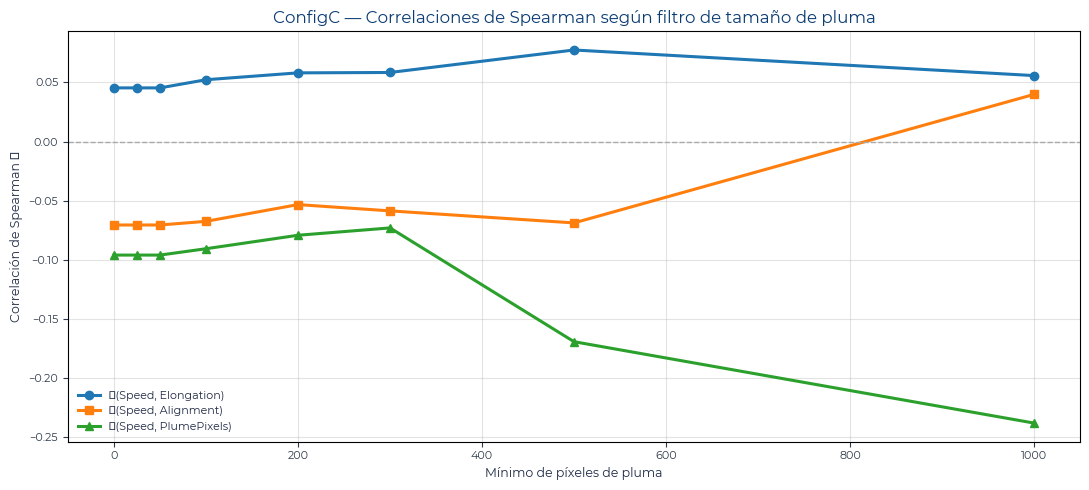

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/07_ConfigC_SpearmanCorrelations_ByPlumeSize.png


In [20]:
Fig, Ax = plt.subplots(figsize=(11, 5))
Ax.plot(RobustAlignment["MinPlumePixels"],
        RobustAlignment["Spearman_WindSpeed_Elongation"],
        marker="o", lw=2.2, label="ρ(Speed, Elongation)")
Ax.plot(RobustAlignment["MinPlumePixels"],
        RobustAlignment["Spearman_WindSpeed_Alignment"],
        marker="s", lw=2.2, label="ρ(Speed, Alignment)")
Ax.plot(RobustAlignment["MinPlumePixels"],
        RobustAlignment["Spearman_WindSpeed_PlumePixels"],
        marker="^", lw=2.2, label="ρ(Speed, PlumePixels)")
Ax.axhline(0, color="#AAAAAA", lw=1.0, ls="--")
Ax.set_title("ConfigC — Correlaciones de Spearman según filtro de tamaño de pluma")
Ax.set_xlabel("Mínimo de píxeles de pluma"); Ax.set_ylabel("Correlación de Spearman ρ")
Ax.legend(frameon=False); Ax.grid(alpha=0.35)
Fig.tight_layout()
OutputFig = OutputFigureDir / "07_ConfigC_SpearmanCorrelations_ByPlumeSize.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


### 5.6 Casos visuales: alta / media / baja alineación

In [21]:
def NormalizeForDisplay(Arr, Pmin=2, Pmax=98):
    Arr    = np.asarray(Arr, dtype=np.float32)
    Finite = Arr[np.isfinite(Arr)]
    if Finite.size == 0:
        return np.zeros_like(Arr)
    Lo, Hi = np.percentile(Finite, [Pmin, Pmax])
    if Hi <= Lo:
        return np.zeros_like(Arr)
    return np.clip((Arr - Lo) / (Hi - Lo), 0, 1)


def PlotCase(Ax, SampleId_):
    Sample = ReadFullTacoSample(
        Dataset=TacoDataset,
        SampleTable=TacoSampleTable,
        SampleId=str(SampleId_),
    )
    Target = np.asarray(Sample["Target"], dtype=np.float32)
    Plume_ = np.asarray(Sample["Plume"]) > 0

    Row = WindPlumeEDA[WindPlumeEDA["SampleId"].astype(str) == str(SampleId_)]
    if Row.empty:
        Ax.set_title("Sin datos"); Ax.axis("off"); return
    Row = Row.iloc[0]

    BaseIdx = min(2, Target.shape[0] - 1)
    Base    = NormalizeForDisplay(Target[BaseIdx])

    Ax.imshow(Base, cmap="gray", vmin=0, vmax=1)
    Ax.imshow(np.ma.masked_where(~Plume_, Plume_.astype(float)),
              cmap="autumn", alpha=0.52, vmin=0, vmax=1)

    Cx, Cy = Row["CentroidCol"], Row["CentroidRow"]
    if not (np.isfinite(Cx) and np.isfinite(Cy)):
        Ax.set_title("Pluma insuficiente", fontsize=9)
        Ax.set_xticks([]); Ax.set_yticks([]); return

    L  = 38
    Wx, Wy = Row["WindDirCos10m"], Row["WindDirSin10m"]
    Ax.arrow(Cx, Cy, L*Wx, -L*Wy, color="#7AD7E5",
             width=1.2, head_width=5.5, length_includes_head=True, zorder=5)

    Theta_ = Row["PlumeAngleMathRad"]
    Px, Py = np.cos(Theta_), np.sin(Theta_)
    Ax.plot([Cx - L*Px, Cx + L*Px], [Cy + L*Py, Cy - L*Py],
            lw=2.4, zorder=6)
    Ax.scatter([Cx], [Cy], s=36, color="white", zorder=7)
    Ax.set_title(
        f"{Row['Split']} | alin = {Row['WindPlumeAlignmentAbsCos']:.2f}\n"
        f"vel = {Row['WindSpeed10m']:.1f} m/s | {int(Row['PlumePixels'])} px",
        fontsize=9.5)
    Ax.set_xticks([]); Ax.set_yticks([])


print("Funciones NormalizeForDisplay y PlotCase definidas.")


Funciones NormalizeForDisplay y PlotCase definidas.


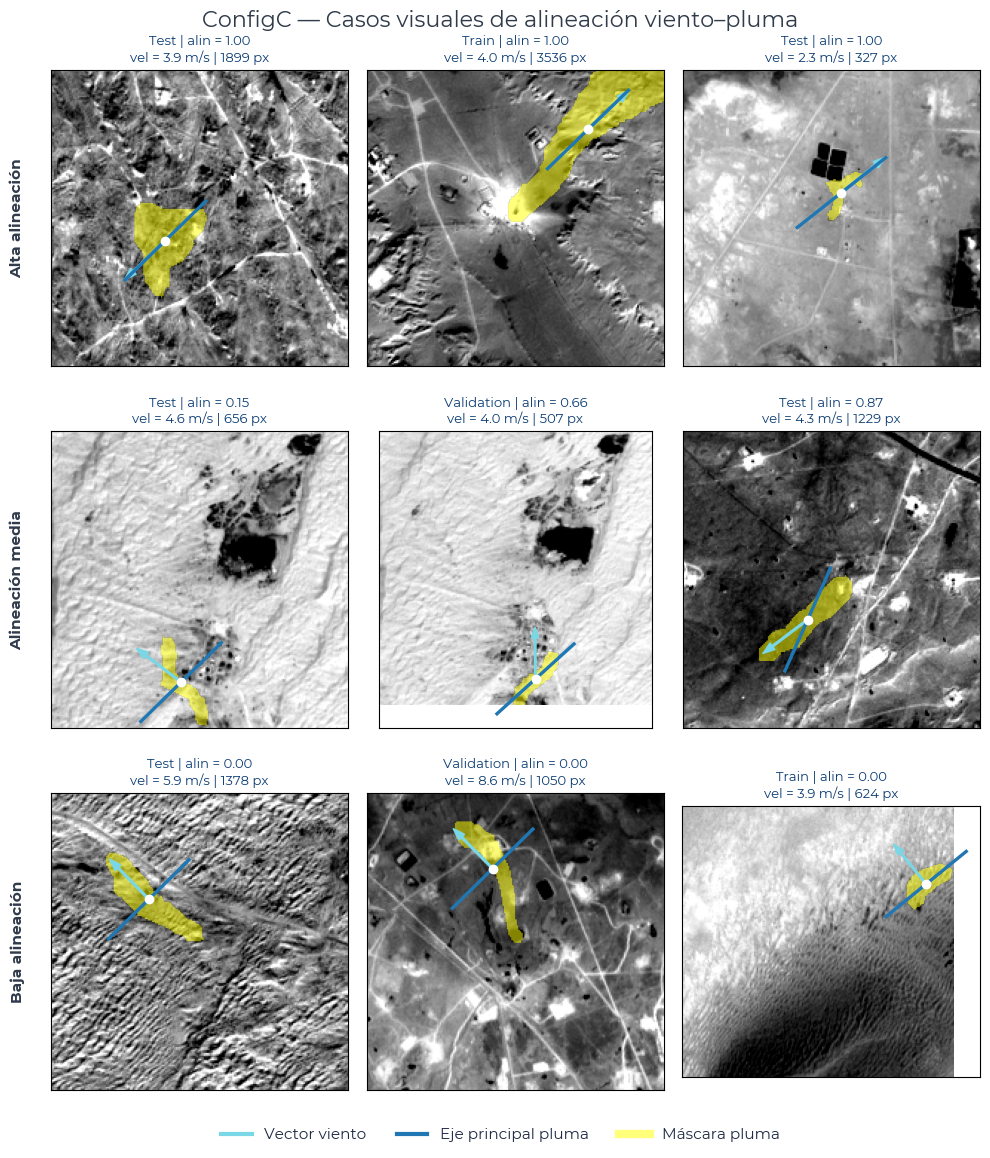

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/08_ConfigC_WindPlume_VectorCases_HighMidLow.png


In [24]:
ValidCases = WindPlumeEDA[
    np.isfinite(WindPlumeEDA["WindPlumeAlignmentAbsCos"])
    & (WindPlumeEDA["PlumePixels"] >= 100)
].copy()

HighCases = ValidCases.nlargest(3,  "WindPlumeAlignmentAbsCos")
LowCases  = ValidCases.nsmallest(3, "WindPlumeAlignmentAbsCos")
MidCases  = ValidCases.iloc[
    (ValidCases["WindPlumeAlignmentAbsCos"] - 0.5).abs().nsmallest(3).index
]

CaseSet = pd.concat([
    HighCases.assign(CaseGroup="Alta alineación"),
    MidCases.assign( CaseGroup="Alineación media"),
    LowCases.assign( CaseGroup="Baja alineación"),
], ignore_index=True)
CaseSet.to_csv(OutputTableDir / "WindPlumeVectorCaseSet.csv", index=False)

Fig, Axes = plt.subplots(3, 3, figsize=(12, 12))

for Ax, (_, Row) in zip(Axes.ravel(), CaseSet.iterrows()):
    PlotCase(Ax, Row["SampleId"])

for I, Label in enumerate(["Alta alineación", "Alineación media", "Baja alineación"]):
    Axes[I, 0].text(-0.09, 0.5, Label,
                    transform=Axes[I, 0].transAxes,
                    rotation=90, va="center", ha="right",
                    fontsize=11, fontweight="bold")

LegendHandles = [
    Line2D([0],[0], color="#7AD7E5", lw=3, label="Vector viento"),
    Line2D([0],[0], lw=3,            label="Eje principal pluma"),
    Line2D([0],[0], color="yellow",     lw=6, alpha=0.52, label="Máscara pluma"),
]
Fig.legend(handles=LegendHandles, loc="lower center",
           ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.015), fontsize=11)
Fig.suptitle("ConfigC — Casos visuales de alineación viento–pluma",
             fontsize=16, y=0.97)
Fig.subplots_adjust(top=0.92, bottom=0.07, wspace=0.06, hspace=0.22)

OutputFig = OutputFigureDir / "08_ConfigC_WindPlume_VectorCases_HighMidLow.png"
Fig.savefig(OutputFig, **SaveKw)
plt.show()
print("Saved:", OutputFig)


## 6. Tabla resumen de justificación ConfigC

In [23]:
EDAFull = WindPlumeEDA[
    np.isfinite(WindPlumeEDA["WindSpeed10m"]) &
    np.isfinite(WindPlumeEDA["Elongation"]) &
    np.isfinite(WindPlumeEDA["PlumePixels"]) &
    np.isfinite(WindPlumeEDA["WindPlumeAlignmentAbsCos"])
].copy()

DecisionSummary = pd.DataFrame([
    {"Criterio": "WindSpeed vs Elongation",
     "Métrica": "Spearman ρ",
     "Valor": EDAFull[["WindSpeed10m","Elongation"]].corr(method="spearman").iloc[0,1],
     "Interpretación": "Relación positiva: vientos más fuertes elongan la pluma."},
    {"Criterio": "WindSpeed vs PlumePixels",
     "Métrica": "Spearman ρ",
     "Valor": EDAFull[["WindSpeed10m","PlumePixels"]].corr(method="spearman").iloc[0,1],
     "Interpretación": "Relación débil: el área depende más de la emisión."},
    {"Criterio": "Alineación viento-pluma",
     "Métrica": "Media |cos(δ)|",
     "Valor": WindPlumeEDA["WindPlumeAlignmentAbsCos"].mean(),
     "Interpretación": "Valor alto indica paralelismo eje pluma – vector viento."},
    {"Criterio": "Alineación viento-pluma",
     "Métrica": "Mediana |cos(δ)|",
     "Valor": WindPlumeEDA["WindPlumeAlignmentAbsCos"].median(),
     "Interpretación": "Mediana alta: la alineación no depende de outliers."},
])
DecisionSummary.to_csv(OutputTableDir / "ConfigC_WindJustificationSummary.csv", index=False)

print("\n=== Tabla de decisión ConfigC ===")
print(DecisionSummary.to_string(index=False))
print("\n✓ Todas las figuras guardadas en:", OutputFigureDir)



=== Tabla de decisión ConfigC ===
                Criterio          Métrica     Valor                                           Interpretación
 WindSpeed vs Elongation       Spearman ρ  0.045377 Relación positiva: vientos más fuertes elongan la pluma.
WindSpeed vs PlumePixels       Spearman ρ -0.095896       Relación débil: el área depende más de la emisión.
 Alineación viento-pluma   Media |cos(δ)|  0.617650 Valor alto indica paralelismo eje pluma – vector viento.
 Alineación viento-pluma Mediana |cos(δ)|  0.685041      Mediana alta: la alineación no depende de outliers.

✓ Todas las figuras guardadas en: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures
